In [1]:
#%pip install langchain-google-genai

import os
from langgraph.graph import StateGraph, START, END
from typing import List, Optional, TypedDict
from dotenv import load_dotenv
# Corrected import for Google Gemini
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI



In [2]:

# Load environment variables
load_dotenv()
google_gemini_api_key = os.getenv("GOOGLE_GEMINI_API_KEY")

# openai_api_key = os.getenv("OPENAI_API_KEY")

In [3]:
gemini_model=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", google_api_key=google_gemini_api_key
)

In [4]:
class PromptChain(TypedDict):
    topic:str
    outline:str
    blog:str

In [5]:
def detail_outline(state:PromptChain)->PromptChain:
    # fetch the topic from the state
    topic=state['topic']

    # write a prompt to generate a detailed outline for the blog based on the topic
    prompt=f"write a detailed outline that guide how to write blog in this topic:{topic}"

    # get the outline from the language model
    outline=gemini_model.invoke(prompt).content

    # update the state with the outline
    state['outline']=outline

    return state

In [6]:
def detail_blog(state:PromptChain)->PromptChain:
    outline=state['outline']

    prompt=f"write a detailed blog based on this outline:{outline}"

    blog=gemini_model.invoke(prompt).content

    state['blog']=blog

    return state

In [8]:
graph=StateGraph(PromptChain)

#add nodes

graph.add_node('TopicOutline', detail_outline)
graph.add_node('BlogDraft', detail_blog)

#add edges

graph.add_edge(START, 'TopicOutline')
graph.add_edge('TopicOutline', 'BlogDraft')
graph.add_edge('BlogDraft', END)

workflow=graph.compile()

In [9]:
initial_state=PromptChain(topic="What is AI?")
final_state=workflow.invoke(initial_state)

print(final_state['blog'])

# What is AI? Your Beginner's Guide to Artificial Intelligence

From sci-fi blockbusters depicting sentient robots to the seamless recommendations on your smartphone, "AI" seems to be everywhere. It's the buzzword dominating tech news, business strategies, and even casual conversations. For many, the term conjures images of supercomputers, job-stealing automatons, or perhaps something intimidatingly complex. But amidst all the hype and speculation, what *is* Artificial Intelligence, really? Is it sentient machines, or just really smart software?

If you've ever felt a little lost in the AI conversation, you're not alone. The rapid pace of technological change often leaves us with more questions than answers. This guide will cut through the jargon and demystify AI, breaking down its core concepts into simple, digestible terms. By the end, you'll have a solid grasp of what AI is, how it works, and how it's already shaping your world. Get ready to explore the true meaning of AI, its found

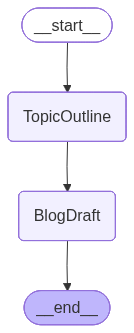

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())